In [1]:
"""

WGAN-GP (Wasserstein GAN with Gradient Penalty)
"Improved Training of Wasserstein GANs" (Gulrajani et al., 2017)

"""

'\n\nWGAN-GP (Wasserstein GAN with Gradient Penalty)\n"Improved Training of Wasserstein GANs" (Gulrajani et al., 2017)\n\n'

In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision

from tqdm import tqdm
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("spandan2/cats-faces-64x64-for-generative-models")

print("Path to dataset files:", path)

100%|██████████| 96.0M/96.0M [00:00<00:00, 208MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/spandan2/cats-faces-64x64-for-generative-models/versions/1


In [4]:
# Optimize convolution algorithms for fixed input sizes to boost training speed
torch.backends.cudnn.benchmark = True

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

total_step = 5000
batch_size = 64
latent_size = 100

lr = 0.0002
lambda_gp = 10

In [6]:
PRINT_INTERVAL = 25
SAMPLE_INTERVAL = 200
CHECKPOINT_INTERVAL = 1000

sample_dir = "./samples"
checkpoint_dir = "./checkpoints"
os.makedirs(sample_dir, exist_ok=True)
os.makedirs(checkpoint_dir, exist_ok=True)

image shape: torch.Size([64, 3, 32, 32])
dataset size: 15747


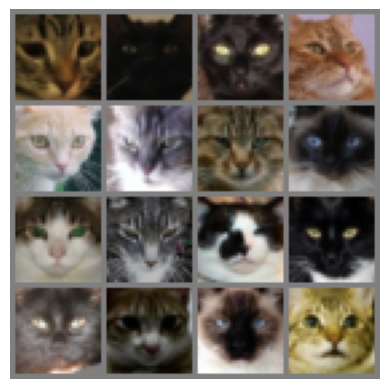

In [7]:
class ImageDataLoader:
    def __init__(self, dataloader):
        self.dataloader = dataloader
        self.iterator = iter(dataloader)

    def __iter__(self):
        return self

    def __next__(self):
        try:
            return next(self.iterator)[0]
        except StopIteration:
            self.iterator = iter(self.dataloader)
            return next(self.iterator)[0]

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = datasets.ImageFolder(root=path, transform=transform)
data_loader = DataLoader(
    dataset=dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)
train_loader = ImageDataLoader(data_loader)

# Test
images = next(iter(train_loader))
print(f"image shape: {images.shape}")
print(f"dataset size: {len(dataset) // 2}")

images = torchvision.utils.make_grid(images[:16], nrow=4)
images = (images + 1) / 2 # [-1, 1] -> [0, 1]
plt.imshow(images.permute(1, 2, 0))
plt.axis("off")
plt.show()

In [8]:
#################### Generator ####################

class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(latent_size, 256 * 4 * 4),
            nn.Unflatten(1, (256, 4, 4)),

            UpBlock(256, 128), # (B, 256, 4, 4)  -> (B, 128, 8, 8)
            UpBlock(128, 64),  # (B, 128, 8, 8)  -> (B, 64, 16, 16)
            UpBlock(64, 32),   # (B, 64, 16, 16) -> (B, 32, 32, 32)

            nn.Conv2d(32, 3, 3, 1, 1), # (B, 3, 32, 32)
            nn.Tanh()
        )

        self.network.apply(init_weights)

    def forward(self, z):
        return self.network(z)

#################### UpBlock ####################

class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear'),
            nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2)
        )

    def forward(self, x):
        return self.up(x)

In [9]:
#################### Discriminator ####################

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            DownBlock(3, 64), # 32 -> 16
            DownBlock(64, 128),                # 16 -> 8
            DownBlock(128, 256),               # 8 -> 4

            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 1),
        )

        self.network.apply(init_weights)

    def forward(self, image):
        return self.network(image)

#################### DownBlock ####################

class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.down = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 2, 1),
            # nn.BatchNorm2d(out_channels) if use_norm else nn.Identity(),
            nn.LeakyReLU(0.2)
        )

    def forward(self, x):
        return self.down(x)

In [10]:
def init_weights(m):
    if isinstance(m, torch.nn.Conv2d) or isinstance(m, torch.nn.ConvTranspose2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
    elif isinstance(m, torch.nn.BatchNorm2d):
        torch.nn.init.normal_(m.weight, 1.0, 0.02)
        torch.nn.init.zeros_(m.bias)

In [11]:
def visualize_sample(fixed_z, step):
    generator.eval()
    with torch.no_grad():
        fake_images = generator(fixed_z).cpu()
        fake_images = (fake_images + 1) / 2  # [-1, 1] -> [0, 1]

        grid = torchvision.utils.make_grid(fake_images, nrow=8)
        plt.figure(figsize=(16, 4))
        plt.imshow(grid.permute(1, 2, 0))
        plt.axis("off")
        plt.tight_layout()
        plt.show()

        torchvision.utils.save_image(
            fake_images,
            f"{sample_dir}/step_{step:03d}.png",
            nrow=8
        )
    generator.train()

def save_checkpoint(step):
    torch.save({
        "step": step,
        "generator": generator.state_dict(),
        "discriminator": discriminator.state_dict(),
        "optimizer_G": optimizer_G.state_dict(),
        "optimizer_D": optimizer_D.state_dict(),
    }, f"{checkpoint_dir}/gan_step_{step:03d}.pth")

def load_checkpoint(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    generator.load_state_dict(checkpoint["generator"])
    discriminator.load_state_dict(checkpoint["discriminator"])
    optimizer_G.load_state_dict(checkpoint["optimizer_G"])
    optimizer_D.load_state_dict(checkpoint["optimizer_D"])
    start_step = checkpoint["step"]
    print(f"Loaded checkpoint: {checkpoint_path} (step {start_step})")
    return start_step

In [12]:
def compute_gradient_penalty(real_images, fake_images):
    B = real_images.size(0)

    alpha = torch.rand(B, 1, 1, 1, device=device)
    interpolates = (alpha * real_images + (1 - alpha) * fake_images.detach()).requires_grad_(True)

    d_interpolates = discriminator(interpolates)

    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=torch.ones_like(d_interpolates),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    gradients = gradients.view(B, -1)
    penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return penalty

In [13]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.0, 0.9))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.0, 0.9))

In [14]:
# if pretrained
# path = "./checkpoints/gan_epoch_1000.pth"
# start_step = load_checkpoint(path)
start_step = 0

WGAN_GP:   0%|          | 0/5000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
D_loss: -6.0382  G_loss: -21.8388  D(x): 26.505  D(G(z)): 21.839:   4%|▍         | 199/5000 [00:23<08:10,  9.79it/s]

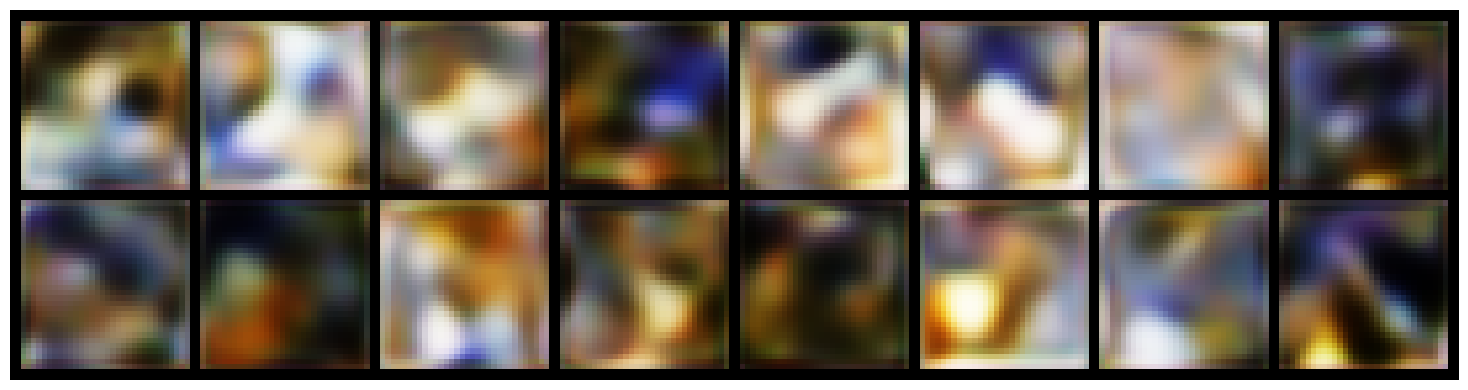

D_loss: -4.5245  G_loss: -9.9684  D(x): 15.746  D(G(z)): 9.968:   8%|▊         | 399/5000 [00:47<07:55,  9.69it/s]  

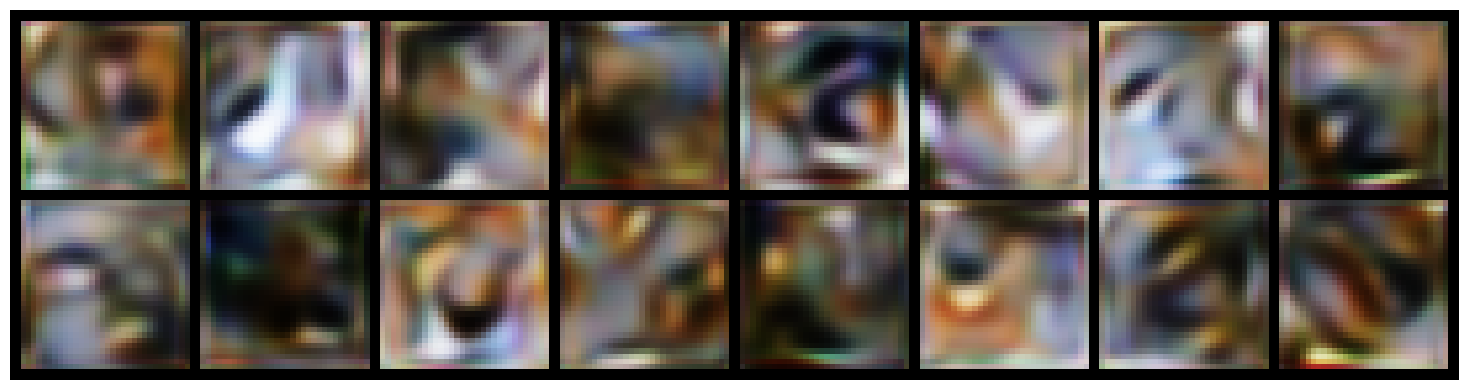

D_loss: -4.1936  G_loss: -19.1415  D(x): 22.505  D(G(z)): 19.142:  12%|█▏        | 598/5000 [01:09<07:53,  9.30it/s]

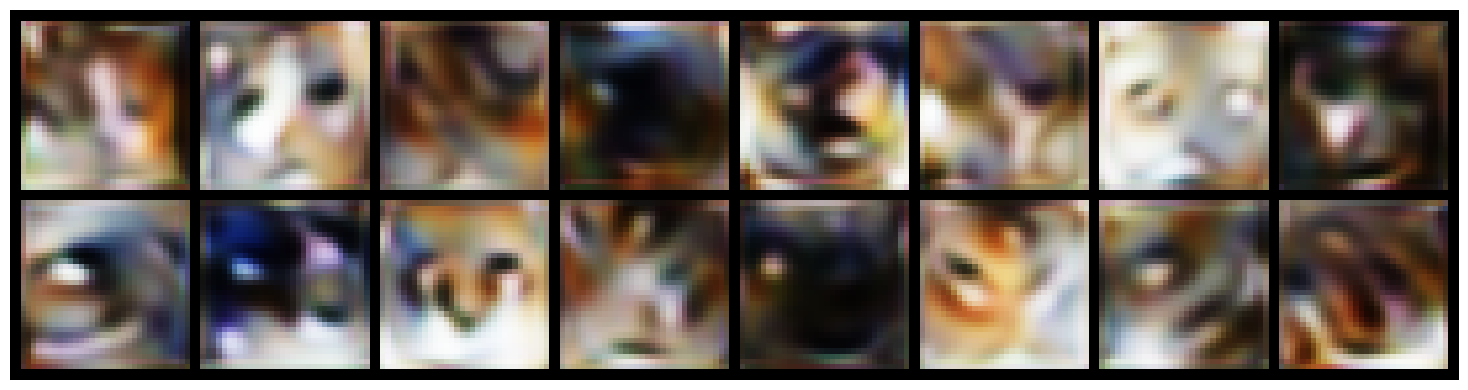

D_loss: -3.1126  G_loss: -16.0752  D(x): 19.698  D(G(z)): 16.075:  16%|█▌        | 799/5000 [01:30<07:25,  9.43it/s]

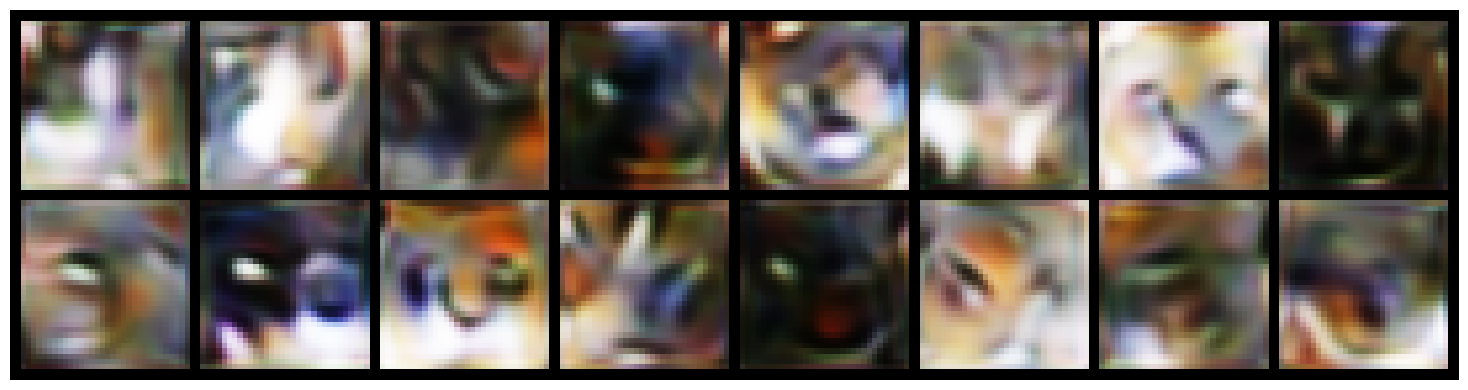

D_loss: -3.7282  G_loss: -17.4167  D(x): 20.756  D(G(z)): 17.417:  20%|█▉        | 999/5000 [01:53<07:16,  9.17it/s]

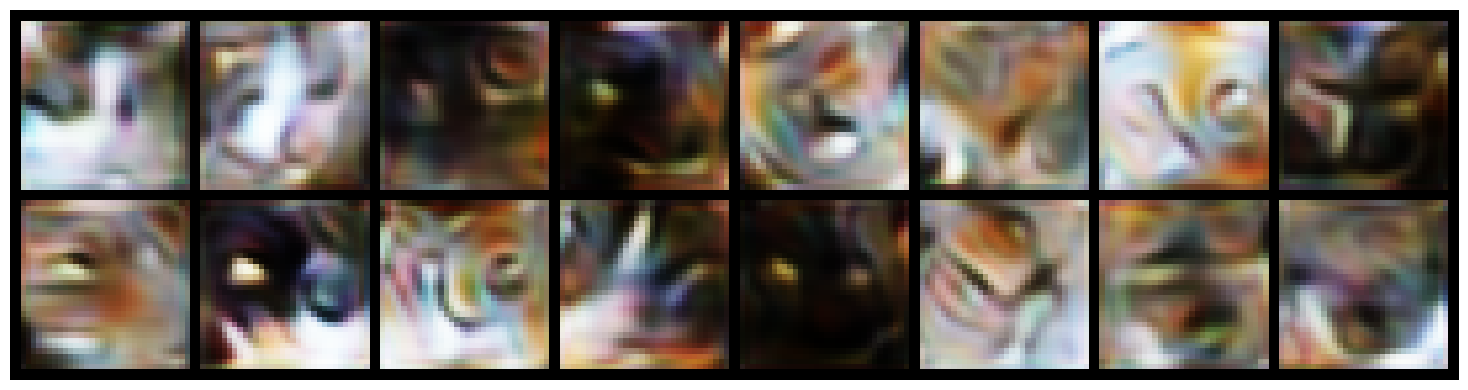

D_loss: -3.8580  G_loss: -11.6524  D(x): 16.414  D(G(z)): 11.652:  24%|██▍       | 1199/5000 [02:16<06:47,  9.33it/s]

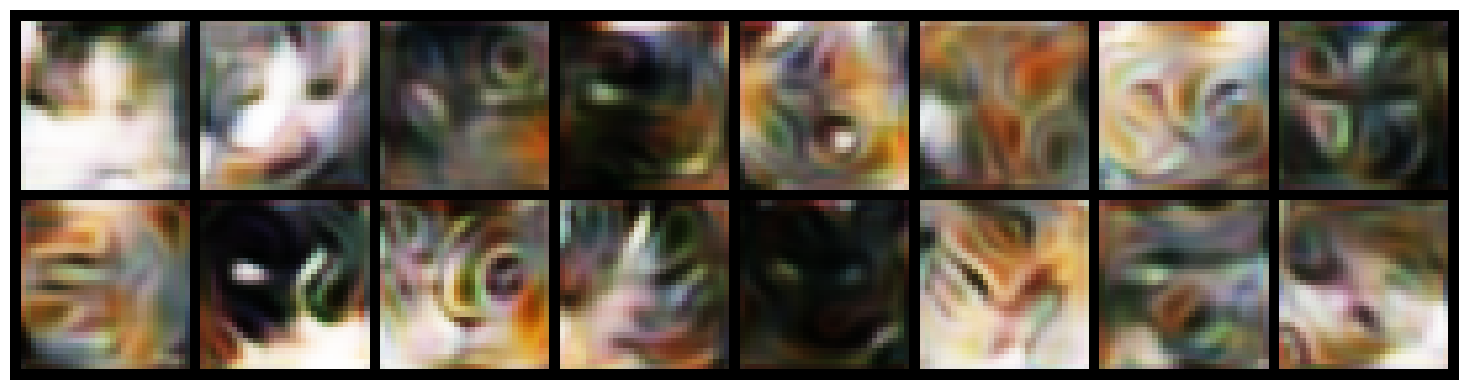

D_loss: -3.4171  G_loss: -25.9952  D(x): 28.973  D(G(z)): 25.995:  28%|██▊       | 1399/5000 [02:38<06:27,  9.30it/s]

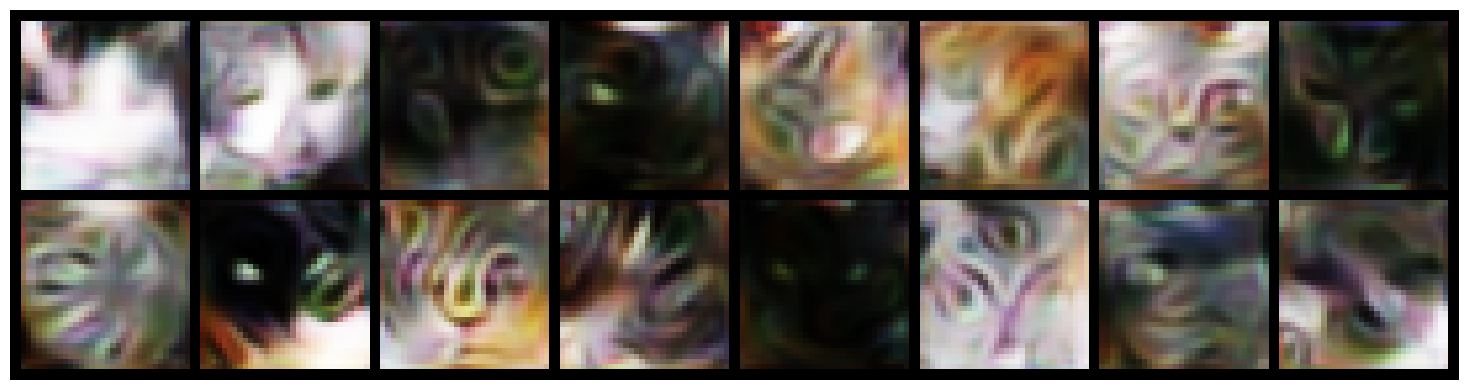

D_loss: -5.3026  G_loss: -16.6241  D(x): 22.240  D(G(z)): 16.624:  32%|███▏      | 1599/5000 [03:00<06:12,  9.13it/s]

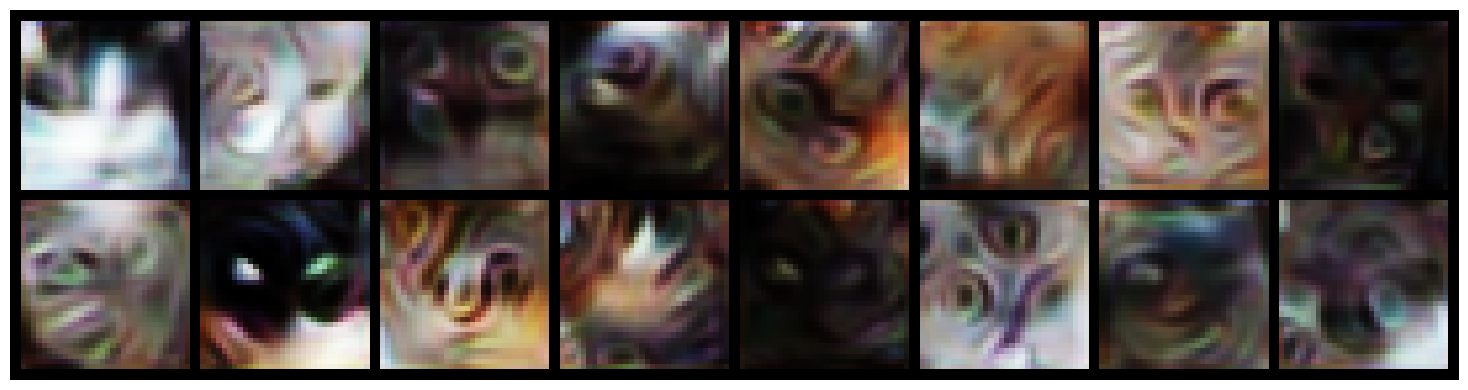

D_loss: -1.9901  G_loss: -18.3503  D(x): 20.553  D(G(z)): 18.350:  36%|███▌      | 1799/5000 [03:22<05:49,  9.16it/s]

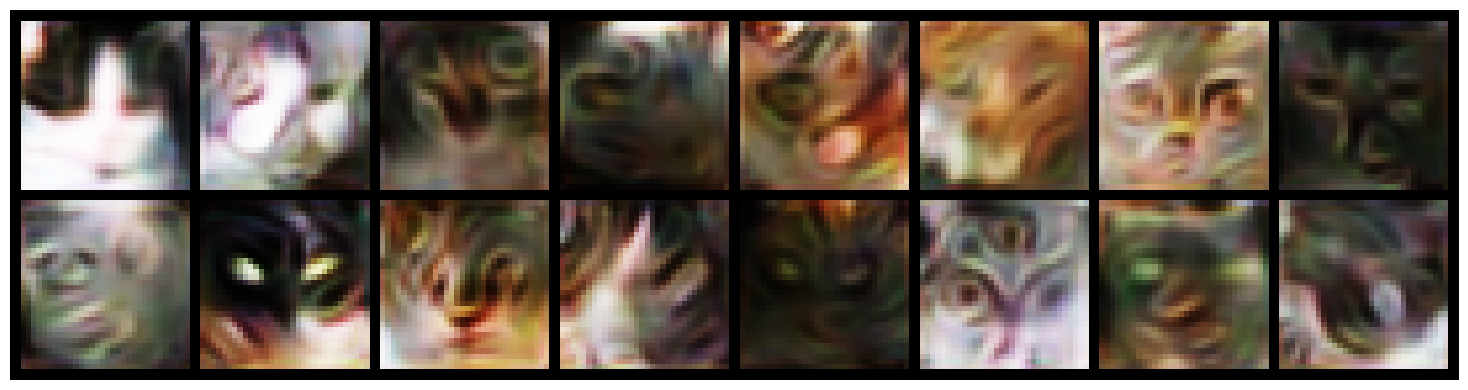

D_loss: -2.6454  G_loss: -9.8279  D(x): 13.183  D(G(z)): 9.828:  40%|███▉      | 1999/5000 [03:44<05:22,  9.31it/s]  

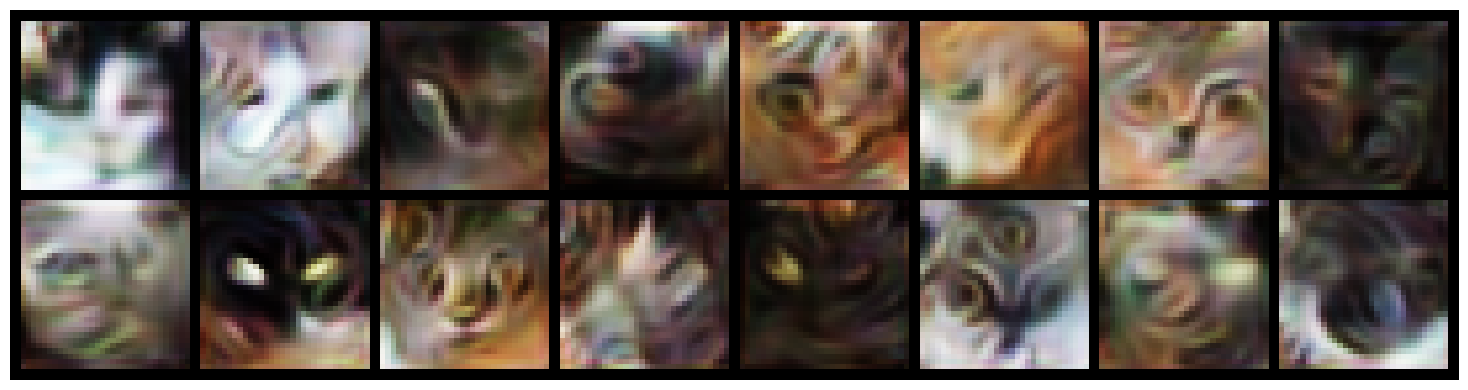

D_loss: -3.2153  G_loss: 6.0330  D(x): -2.677  D(G(z)): -6.033:  44%|████▍     | 2199/5000 [04:06<05:00,  9.33it/s]  

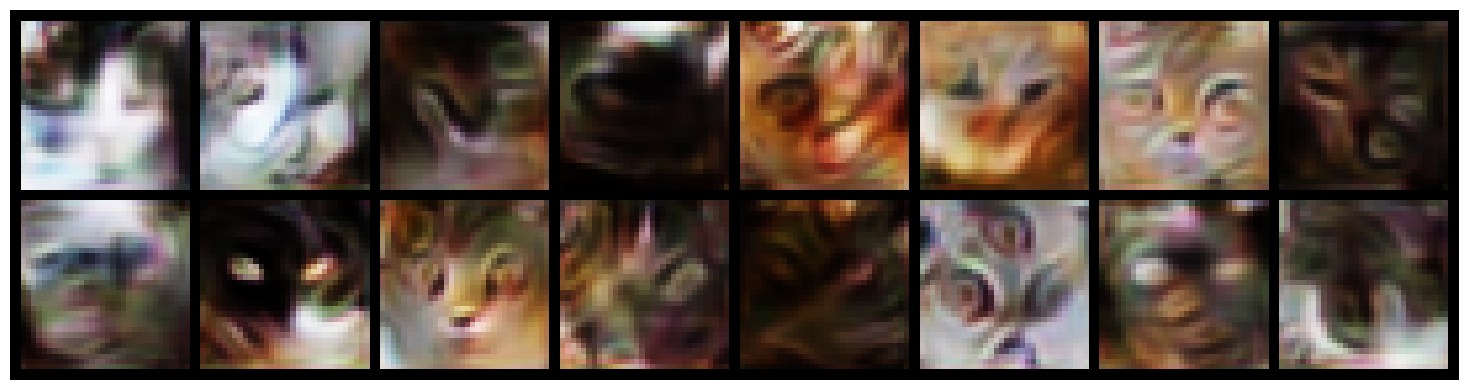

D_loss: -2.9871  G_loss: -4.6125  D(x): 7.523  D(G(z)): 4.613:  48%|████▊     | 2399/5000 [04:28<04:43,  9.18it/s]   

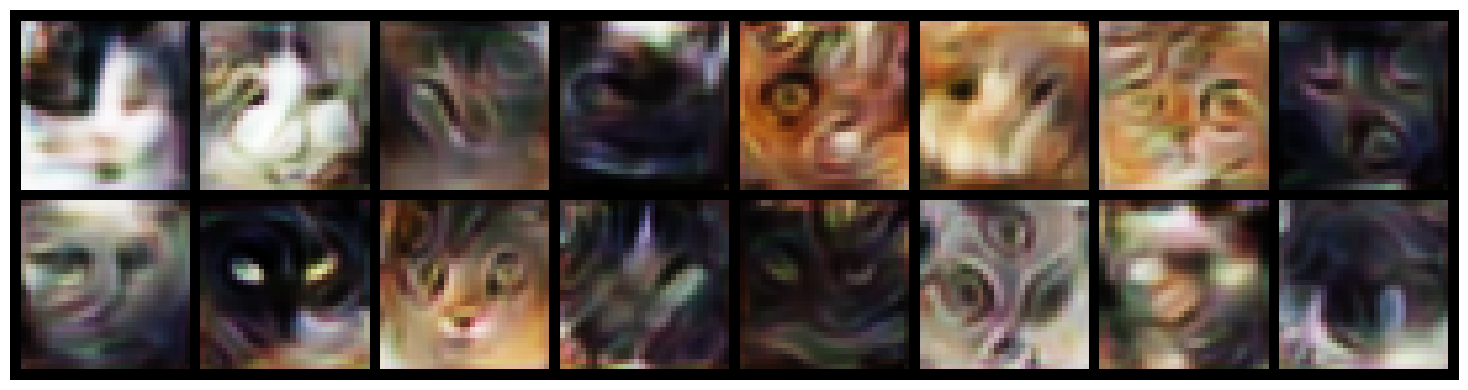

D_loss: -2.0516  G_loss: -9.2378  D(x): 9.930  D(G(z)): 9.238:  52%|█████▏    | 2599/5000 [04:51<04:17,  9.31it/s]   

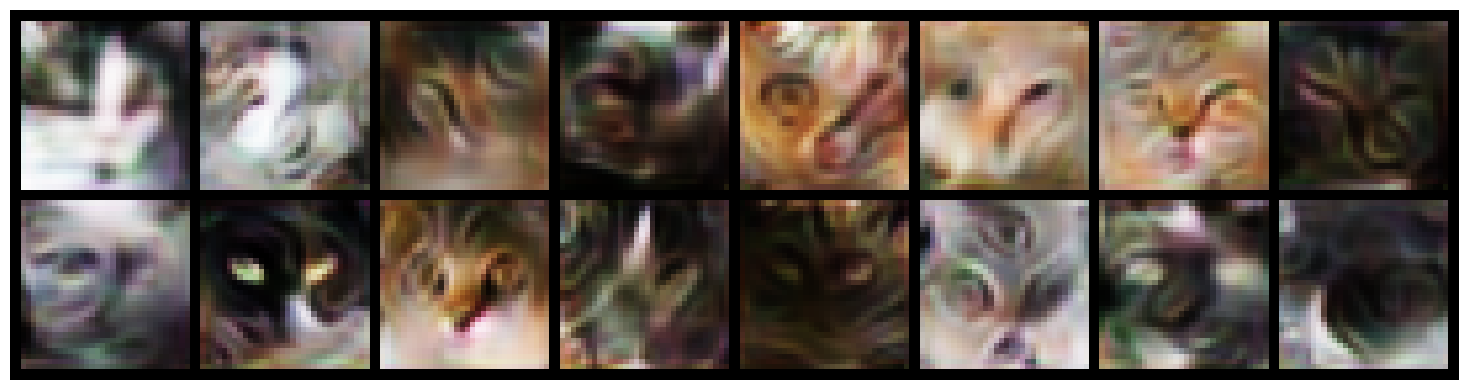

D_loss: -3.3274  G_loss: -9.0337  D(x): 13.189  D(G(z)): 9.034:  56%|█████▌    | 2799/5000 [05:13<03:56,  9.32it/s]

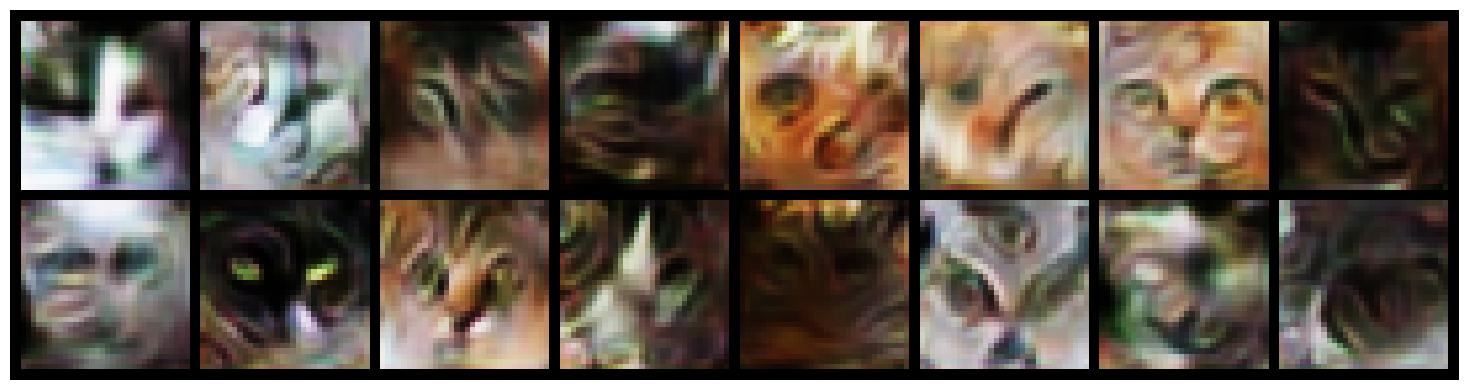

D_loss: -2.2075  G_loss: -9.4241  D(x): 11.632  D(G(z)): 9.424:  60%|█████▉    | 2999/5000 [05:35<03:40,  9.08it/s]

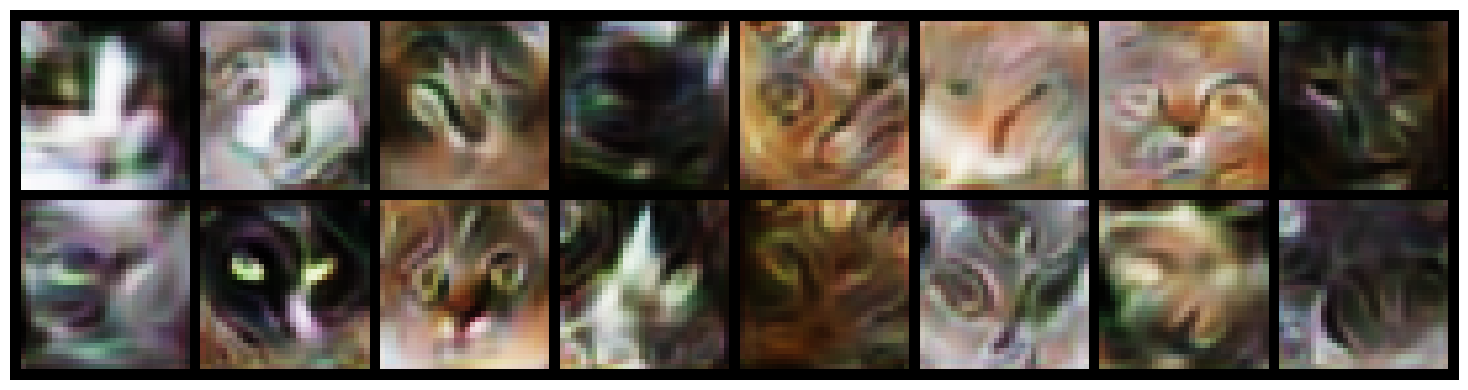

D_loss: -2.6682  G_loss: -17.2853  D(x): 20.744  D(G(z)): 17.285:  64%|██████▍   | 3199/5000 [05:57<03:13,  9.31it/s]

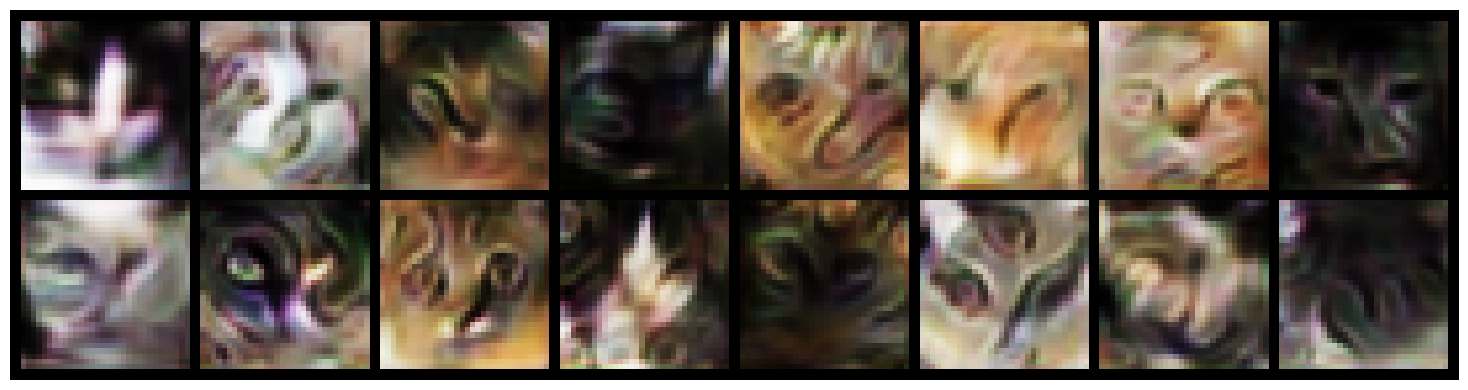

D_loss: -2.1542  G_loss: -10.9741  D(x): 13.728  D(G(z)): 10.974:  68%|██████▊   | 3399/5000 [06:20<02:53,  9.24it/s]

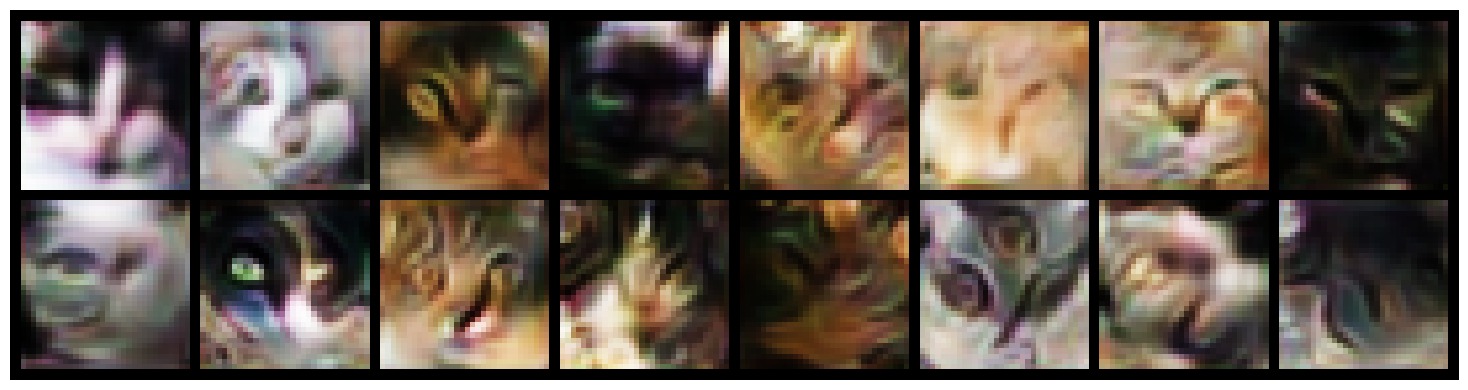

D_loss: -1.7696  G_loss: -7.4030  D(x): 8.842  D(G(z)): 7.403:  72%|███████▏  | 3598/5000 [06:42<02:37,  8.88it/s]   

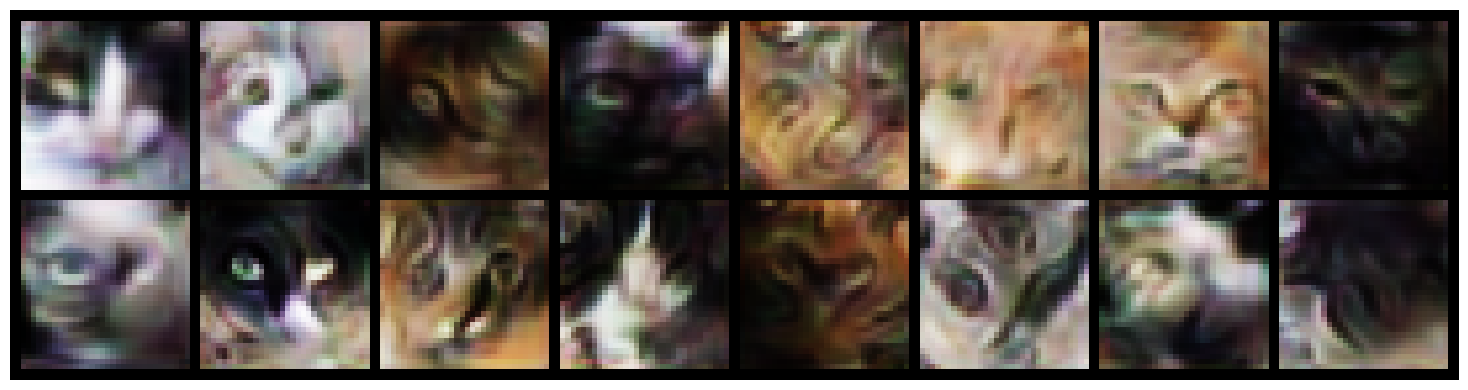

D_loss: -2.9918  G_loss: -17.7999  D(x): 19.462  D(G(z)): 17.800:  76%|███████▌  | 3799/5000 [07:04<02:09,  9.25it/s]

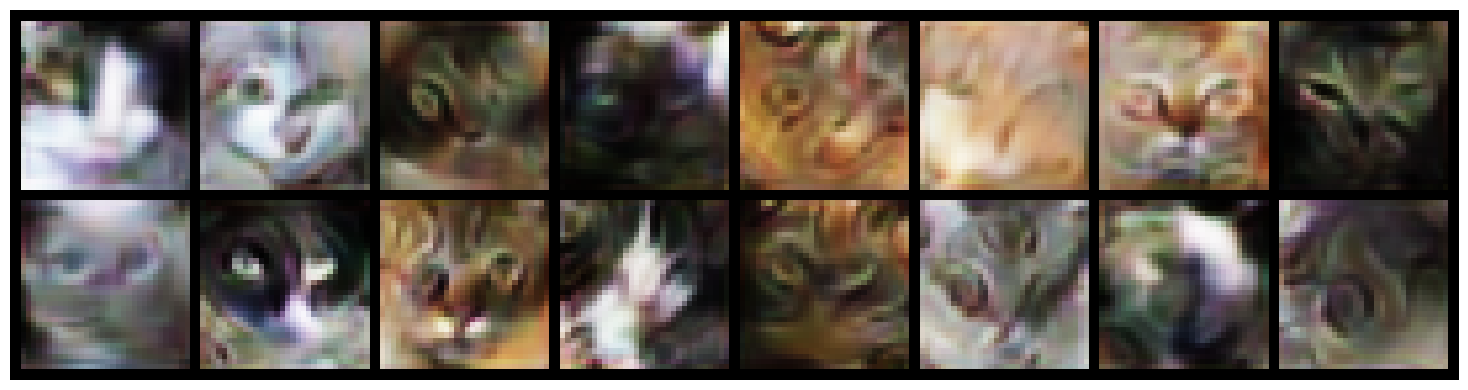

D_loss: -2.6545  G_loss: 0.7098  D(x): 1.609  D(G(z)): -0.710:  80%|███████▉  | 3999/5000 [07:26<01:48,  9.19it/s]   

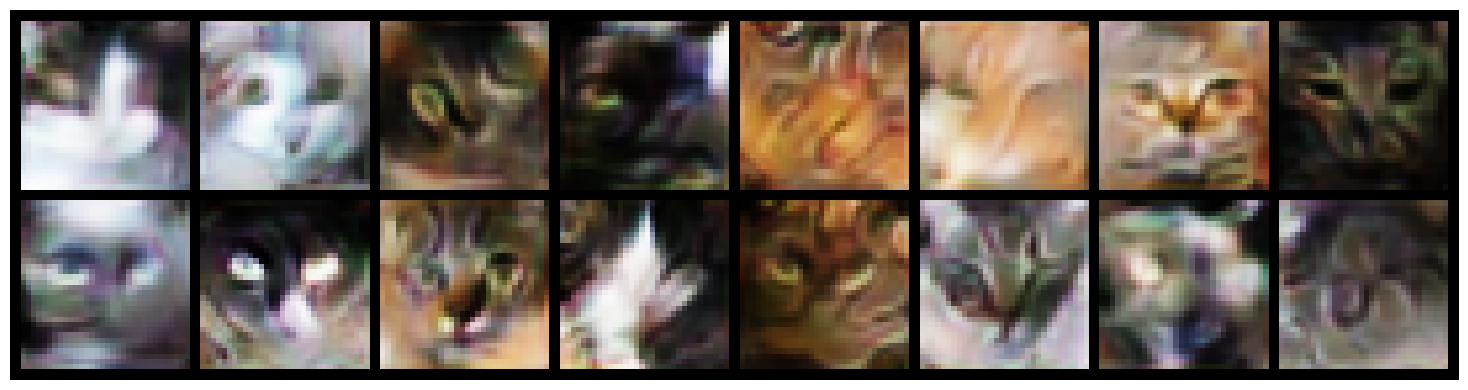

D_loss: -2.3831  G_loss: -15.3319  D(x): 17.698  D(G(z)): 15.332:  84%|████████▍ | 4199/5000 [07:49<01:26,  9.27it/s]

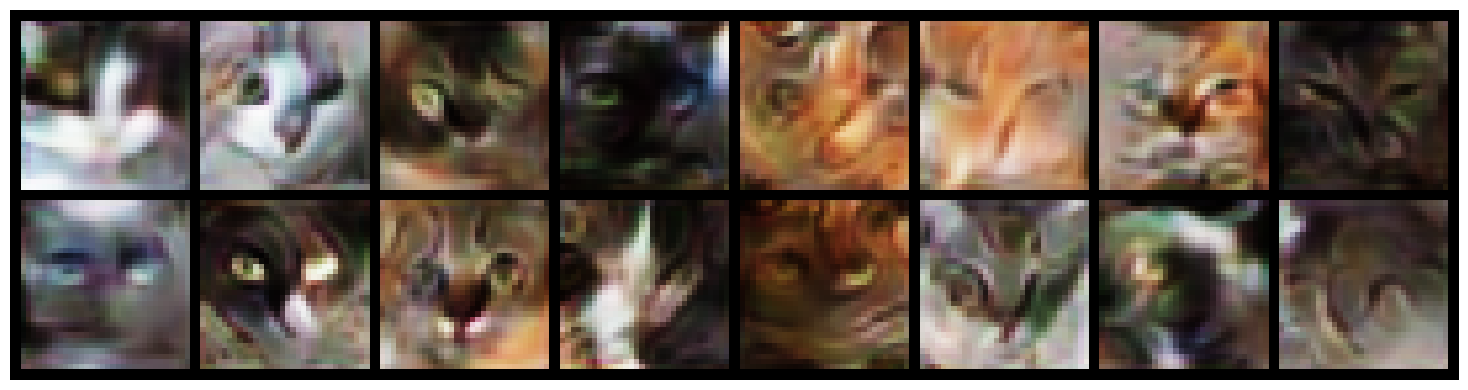

D_loss: -2.5279  G_loss: -12.5541  D(x): 15.724  D(G(z)): 12.554:  88%|████████▊ | 4399/5000 [08:11<01:06,  9.08it/s]

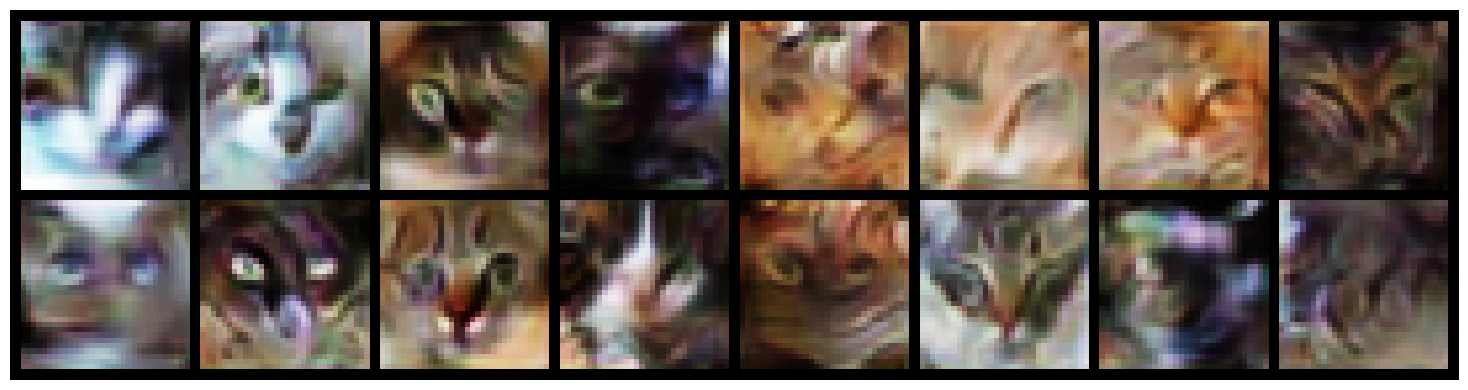

D_loss: -3.2259  G_loss: -21.3886  D(x): 23.264  D(G(z)): 21.389:  92%|█████████▏| 4599/5000 [08:33<00:43,  9.19it/s]

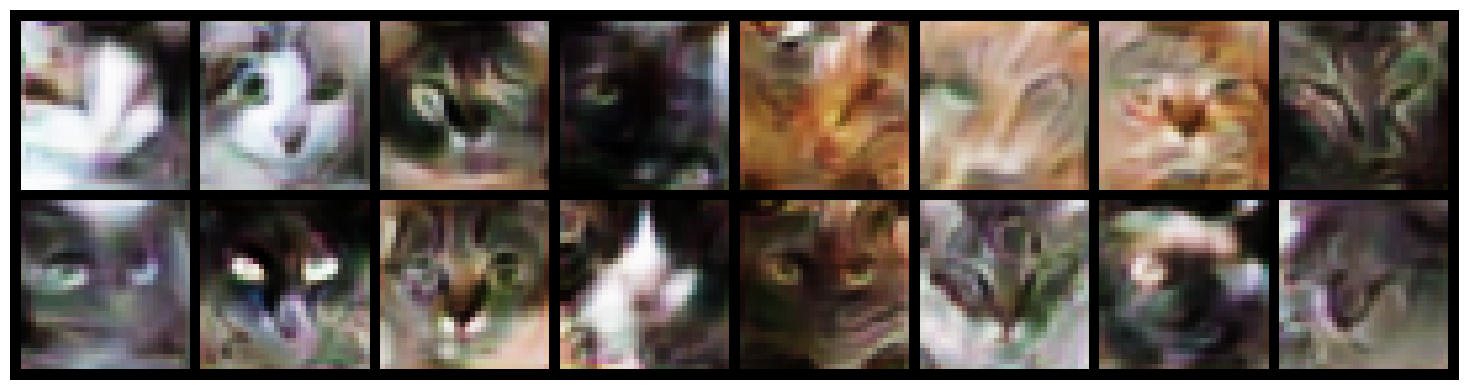

D_loss: -4.8203  G_loss: -32.6224  D(x): 38.818  D(G(z)): 32.622:  96%|█████████▌| 4799/5000 [08:56<00:21,  9.26it/s]

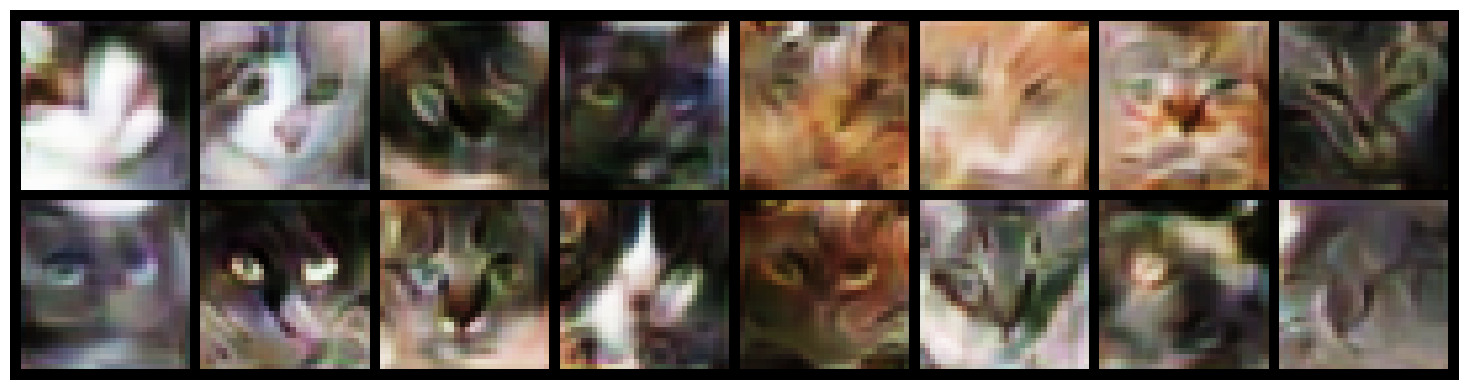

D_loss: -1.6312  G_loss: -7.2959  D(x): 12.114  D(G(z)): 7.296: 100%|█████████▉| 4999/5000 [09:18<00:00,  9.29it/s]  

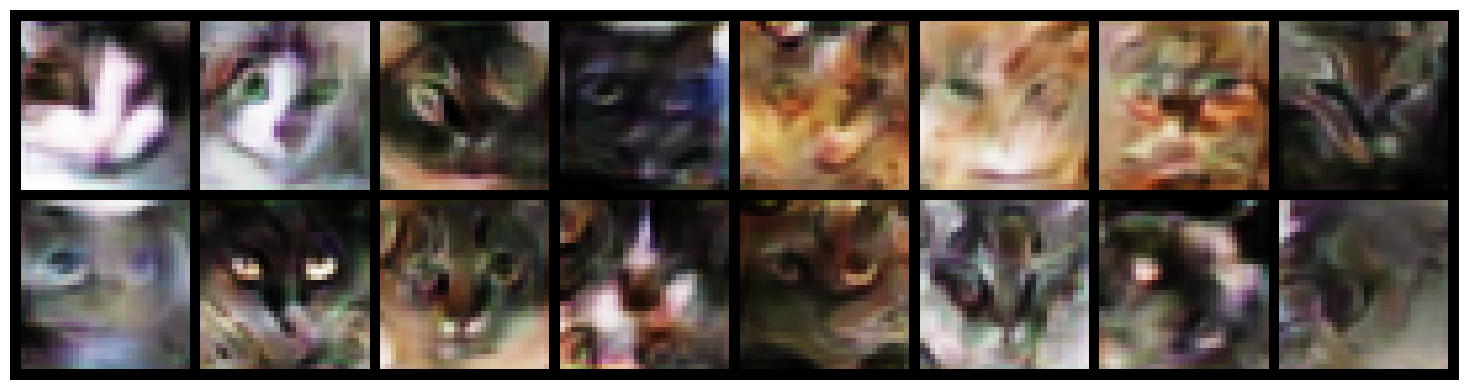

D_loss: -1.6312  G_loss: -7.2959  D(x): 12.114  D(G(z)): 7.296: 100%|██████████| 5000/5000 [09:18<00:00,  8.95it/s]


In [15]:
########## Train ##########

fixed_z_generator = torch.Generator(device=device).manual_seed(42)
fixed_z = torch.randn(16, latent_size, generator=fixed_z_generator, device=device) # for eval
# real_targets = torch.ones(batch_size, 1, device=device)  # (b, 1)
# fake_targets = torch.zeros(batch_size, 1, device=device) # (b, 1)

pbar = tqdm(range(start_step, total_step), desc="WGAN_GP")

for step in pbar:
    real_images = next(train_loader).to(device)

    ########## D Train ##########
    for _ in range(5):
        z = torch.randn(batch_size, latent_size, device=device)
        with torch.no_grad():
            fake_images = generator(z)

        d_real = discriminator(real_images)
        d_fake = discriminator(fake_images)

        gradient_penalty = compute_gradient_penalty(real_images, fake_images)

        loss_D = -torch.mean(d_real) + torch.mean(d_fake) + gradient_penalty * lambda_gp

        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

    ########## G Train ##########
    z = torch.randn(batch_size, latent_size, device=device)
    fake_images = generator(z)
    d_fake = discriminator(fake_images)
    loss_G = -torch.mean(d_fake)

    optimizer_G.zero_grad()
    loss_G.backward()
    optimizer_G.step()

    ########## Log ##########

    if (step + 1) % PRINT_INTERVAL == 0:
        pbar.set_description(
            f"D_loss: {loss_D.item():.4f}  G_loss: {loss_G.item():.4f}  "
            f"D(x): {d_real.mean().item():.3f}  D(G(z)): {d_fake.mean().item():.3f}"
        )

    if (step + 1) % SAMPLE_INTERVAL == 0:
        visualize_sample(fixed_z, step + 1)

    if (step + 1) % CHECKPOINT_INTERVAL == 0:
        save_checkpoint(step + 1)